# Iris Classification — Exploratory Data Analysis

## 1. Data Loading & Initial Overview

### Why We Are Doing This Step
Before building machine learning models, we must inspect the raw dataset. We need to check the dataset shape, confirm there are no missing values, and verify that all target classes are balanced so our models do not develop a bias toward any single species.

### Key Takeaways
* **Dataset Size:** 149 rows after removing 1 duplicate, and 4 numerical measurements
* **Data Quality:** 0 missing or empty entries across all columns.
* **Class Balance:**  Setosa 50 / Versicolor 50 / Virginica 49 — one duplicate row removed from Virginica

In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

# Set global visual style
sns.set_theme(style="whitegrid", palette="viridis")

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
df = df.drop_duplicates().reset_index(drop=True)
df["species_name"] = df["species"]

# Inspect dataset dimensions and class distributions
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df["species"].value_counts())
df.head()

Dataset Shape: (149, 6)

Class Distribution:
 species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,setosa,setosa
1,4.9,3.0,1.4,0.2,setosa,setosa
2,4.7,3.2,1.3,0.2,setosa,setosa
3,4.6,3.1,1.5,0.2,setosa,setosa
4,5.0,3.6,1.4,0.2,setosa,setosa


## 2. Statistical Summary & Feature Distributions

### What This Chart Shows
The boxplot below displays the spread, median values, and range for every feature grouped by species. Black dots represent individual data points, while the boxes highlight where the central 50% of the data falls.

### Key Observations & Purpose
* **Clear Class Separation:** `setosa` has dramatically smaller and tighter values in `petal length` and `petal width` compared to `versicolor` and `virginica`.
* **Scale Differences:** Feature values live on different numerical scales (e.g., sepal measurements are larger than petal measurements).
* **Pipeline Impact:** Because these features operate on different scales, applying `StandardScaler` during model preprocessing is necessary so high-value features do not distort model training.

In [ ]:
plt.show()

sepal length (cm)           sepal width (cm)            \
                        mean       std             mean       std   
species                                                             
setosa              5.006000  0.352490         3.428000  0.379064   
versicolor          5.936000  0.516171         2.770000  0.313798   
virginica           6.604082  0.632113         2.979592  0.323380   

           petal length (cm)           petal width (cm)            
                        mean       std             mean       std  
species                                                            
setosa              1.462000  0.173664         0.246000  0.105386  
versicolor          4.260000  0.469911         1.326000  0.197753  
virginica           5.561224  0.553706         2.028571  0.276887

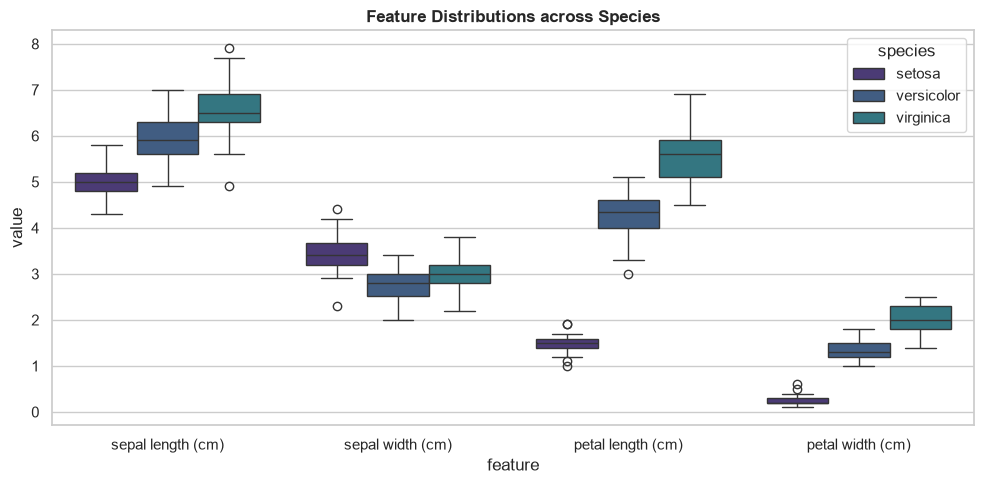

In [4]:

# Grouped descriptive statistics
display(df.drop(columns=["species_name"]).groupby("species").agg(["mean", "std"]))

# Boxplots for distribution spread across features
plt.figure(figsize=(10, 5))
df_melted = pd.melt(
    df, id_vars=["species"], value_vars=iris.feature_names, var_name="feature", value_name="value"
)
sns.boxplot(x="feature", y="value", hue="species", data=df_melted)
plt.title("Feature Distributions across Species", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Feature Correlations & Decision Boundaries

### What These Charts Show
1. **Correlation Heatmap:** Measures how strongly two features move together. A value near `1.00` means two features carry almost identical information.
2. **Pairplot Matrix:** Plots every feature against every other feature, color-coded by species, allowing us to inspect decision boundaries visually.

### Key Observations & Purpose
* **High Multicollinearity:** `petal length` and `petal width` have an extremely high correlation ($r = 0.96$). They carry nearly identical signals into our machine learning models.
* **Linear vs. Non-Linear Boundaries:**
  * `setosa` forms an isolated cluster and is **100% linearly separable** using petal measurements alone.
  * `versicolor` and `virginica` share slight overlap across sepal dimensions, meaning multi-class boundary algorithms are required to separate them cleanly.

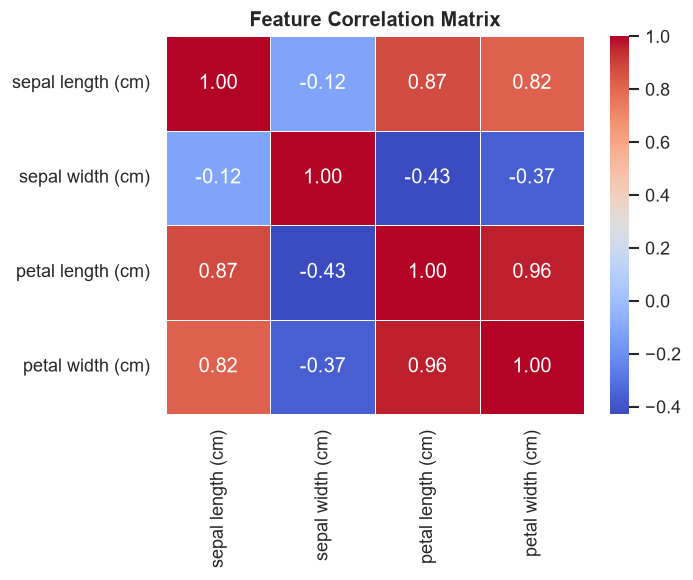

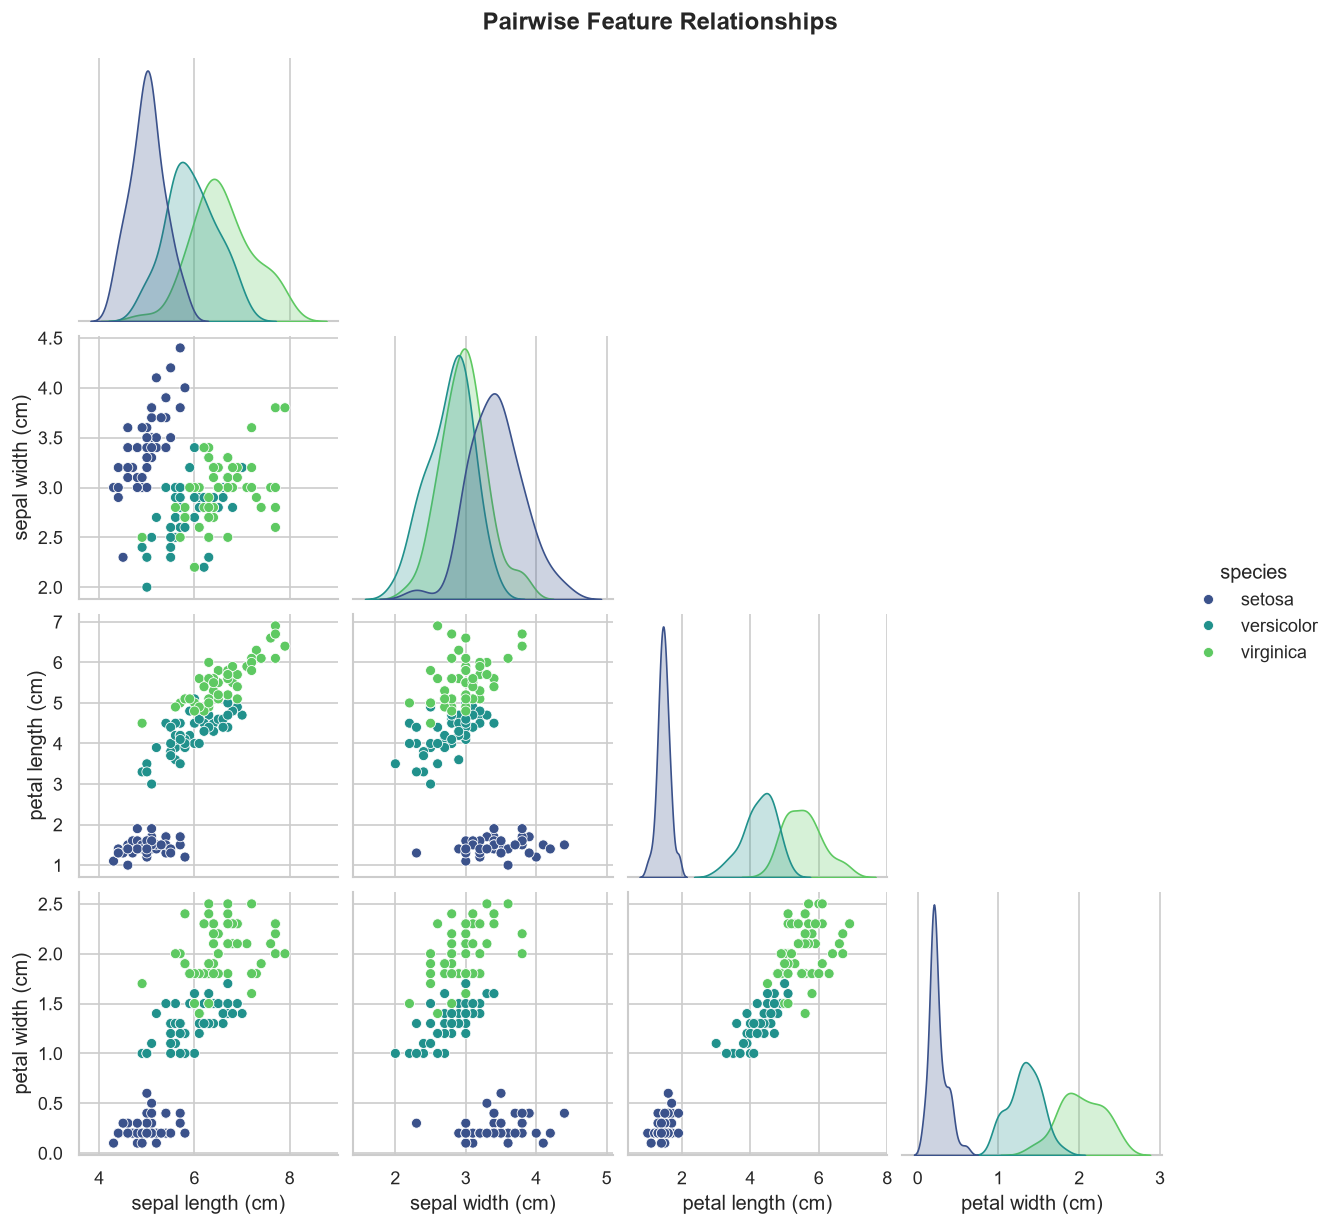

In [8]:

# Pearson correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    df.drop(columns=["species"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

# Pairwise scatter plots to inspect class boundaries
sns.pairplot(df, hue="species", corner=True, palette="viridis")
plt.suptitle("Pairwise Feature Relationships", y=1.02, fontweight="bold")
plt.show()

### Class Balance
Classes are nearly balanced (50/50/49), so there's no meaningful class imbalance to
correct for — accuracy is a fair metric here without needing techniques
like oversampling or weighted loss.

Text(0.5, 1.0, 'Class Balance')

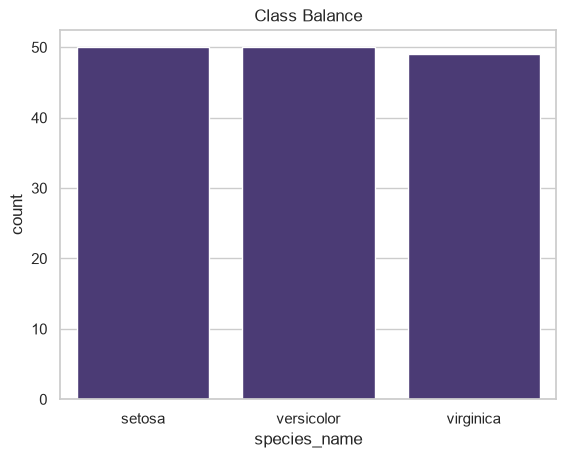

In [5]:
sns.countplot(data=df, x='species_name')
plt.title('Class Balance')


## Conclusion

The EDA confirms that the dataset contains **3 nearly balanced target classes** (50/50/49) with zero missing values after removing 1 duplicate row. Petal measurements (`petal length` and `petal width`) are the most discriminative features, with high correlation ($r = 0.96$), and `setosa` is completely linearly separable from the other two species. However, `versicolor` and `virginica` exhibit slight decision boundary overlap across sepal dimensions. 

This explains why baseline models like KNN or Logistic Regression achieve high accuracy on this dataset—`setosa` is easily isolated in feature space, while feature scaling (`StandardScaler`) and multi-class estimators resolve the boundary between `versicolor` and `virginica`. See `train.py` for the full model comparison and `README.md` for final results.